In [7]:
import snowflake.connector
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

**Q3**

In [3]:
!which dbt

/home/samuelnegus/miniconda3/bin/dbt


**Q9**

In [4]:
!grep -v password ~/.dbt/profiles.yml

p4_data_pipeline:
  target: dev # default target; can be switched using --target option of dbt run
  outputs:
    dev:
      type: snowflake
      account: JF80909.us-central1.gcp  # Example: <account_name>.<region>.<cloud_provider>
      user: SAMUELNEGUS
      role: p4_role
      database: survey_database 
      warehouse: p4_warehouse
      schema: survey_schema
      threads: 10


In [5]:
!cat ~/p4_data_pipeline/models/schema.yml

version: 2

sources:
  - name: survey
    database: survey_database
    schema: survey_schema
    tables:
      - name: survey


In [6]:
!cat ~/p4_data_pipeline/models/staging/transform_survey.sql

with raw_survey as (
    select * from {{ source('survey', 'survey') }}
),

survey_transformed as (
    select
        {{ adapter.quote('EMAIL_ADDRESS') }} as email,
        {{ adapter.quote('ARE_YOU_A_RUNNER_CONSIDER_BOTH_RUNNING_ON_TREADMILL_AND_OUTDOORS_') }} as is_runner,
        {{ adapter.quote('DO_YOU_CONSIDER_YOURSELF_A_PROCRASTINATOR_') }} as is_procrastinator,
        {{ adapter.quote('HAVE_YOU_EVER_IN_YOUR_LIFE_HAD_A_PET_') }} as has_pet,
        {{ adapter.quote('IF_YOU_HAD_AN_EXTRA_HOUR_IN_YOUR_DAY_HOW_WOULD_YOU_SPEND_IT_') }} as extra_hour_use,
        {{ adapter.quote('IF_YOU_HAVE_SECONDARY_MAJORS_PLEASE_LIST_THEM_HERE_SEPARATED_BY_A_COMMA_') }} as secondary_major,
        {{ adapter.quote('WHAT_FACTOR_INFLUENCES_YOUR_COURSE_SELECTION_THE_MOST_') }} as course_factor,
        {{ adapter.quote('WHAT_IS_THE_5_DIGIT_ZIP_CODE_OF_YOUR_RESIDENCE_WHILE_ATTENDING_CLASSES_IF_YOU_ARE_NOT_SURE_CHECK_HERE_HTTPS_TOOLS_USPS_COM_ZIP_CODE_LOOKUP_HTM_BYADDRESS_') }} as zip_code,
        {

In [9]:
with open("snowflake_password", "r") as file:
    snowflake_password = file.read().strip()

In [10]:
conn = snowflake.connector.connect(
    user='SAMUELNEGUS',
    password=snowflake_password,
    account='JF80909.us-central1.gcp'
)

cursor = conn.cursor()

In [11]:
cursor.execute("USE ROLE p4_role;")
cursor.execute("USE DATABASE survey_database;")
cursor.execute("USE SCHEMA survey_schema;")
cursor.execute("USE WAREHOUSE p4_warehouse;")

df = pd.read_sql("""
SELECT * FROM transform_survey
LIMIT 10;
""", conn)
df.head()

/tmp/ipykernel_2219033/2675448580.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("""


,EMAIL,IS_RUNNER,IS_PROCRASTINATOR,HAS_PET,EXTRA_HOUR_USE,SECONDARY_MAJOR,COURSE_FACTOR,ZIP_CODE,AGE,STANDING,FAVORITE_HOBBY,FAVORITE_TOPPING,PRIMARY_MAJOR,EARLY_OR_NIGHT
0,igallucci@wisc.edu,No,Maybe,Yes,Working on a hobby,None,Interest in the subject,53703,22,Senior,Watching Movies,none (just cheese),Data Science,no preference
1,jwcramer2@wisc.edu,No,No,Yes,Working on a hobby,None,Career relevance,53726,21,Senior,Playing the piano.,basil/spinach,Data Science,night owl
2,jzhang2752@wisc.edu,No,Yes,Yes,Sleeping,Statistics,Graduation requirements,53706,20,Sophomore,Dance,pepperoni,Data Science,night owl
3,entackett@wisc.edu,No,Maybe,No,Sleeping,None,Career relevance,53715,20,Senior,Learning mathematics in my free time,pepperoni,Mathematics/AMEP,night owl
4,snegus@wisc.edu,Yes,Maybe,Yes,Working on a hobby,Digital Media Analytics,Interest in the subject,53703,21,Junior,Downhill skiing,mushroom,Data Science,night owl


**Q10: What is the least common primary major in the course, according to the survey?**

In [20]:
q10 = pd.read_sql("""
    SELECT primary_major, COUNT(*) AS count
    FROM transform_survey
    GROUP BY primary_major
    ORDER BY count ASC
""", conn)

q10

/tmp/ipykernel_2212783/658757339.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  q10 = pd.read_sql("""


,PRIMARY_MAJOR,COUNT
0,Other,1
1,Business: Other,1
2,Business: Actuarial,1
3,Business: Information Systems,1
4,Science: Physics,2
5,Statistics,2
6,Engineering: Other,2
7,Mathematics/AMEP,4
8,Data Science,69
9,Computer Science,76


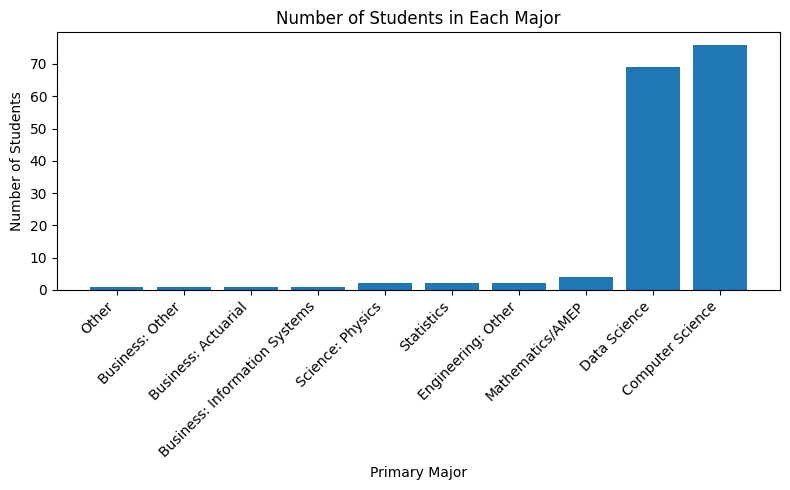

In [23]:
plt.figure(figsize=(8, 5))
plt.bar(q10['PRIMARY_MAJOR'], q10['COUNT'])
plt.xticks(rotation=45, ha='right')
plt.title('Number of Students in Each Major')
plt.xlabel('Primary Major')
plt.ylabel('Number of Students')
plt.tight_layout()
plt.show()

**Q11: What are Students Favorite Pizza Toppings?**

In [26]:
q11 = pd.read_sql("""
    SELECT favorite_topping AS topping, COUNT(*) AS count
    FROM transform_survey
    GROUP BY favorite_topping
    ORDER BY count DESC
""", conn)

q11

/tmp/ipykernel_2212783/4035388326.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  q11 = pd.read_sql("""


,TOPPING,COUNT
0,pepperoni,45
1,pineapple,22
2,Other,20
3,sausage,19
4,mushroom,17
5,basil/spinach,12
6,none (just cheese),11
7,green pepper,11
8,macaroni/pasta,2


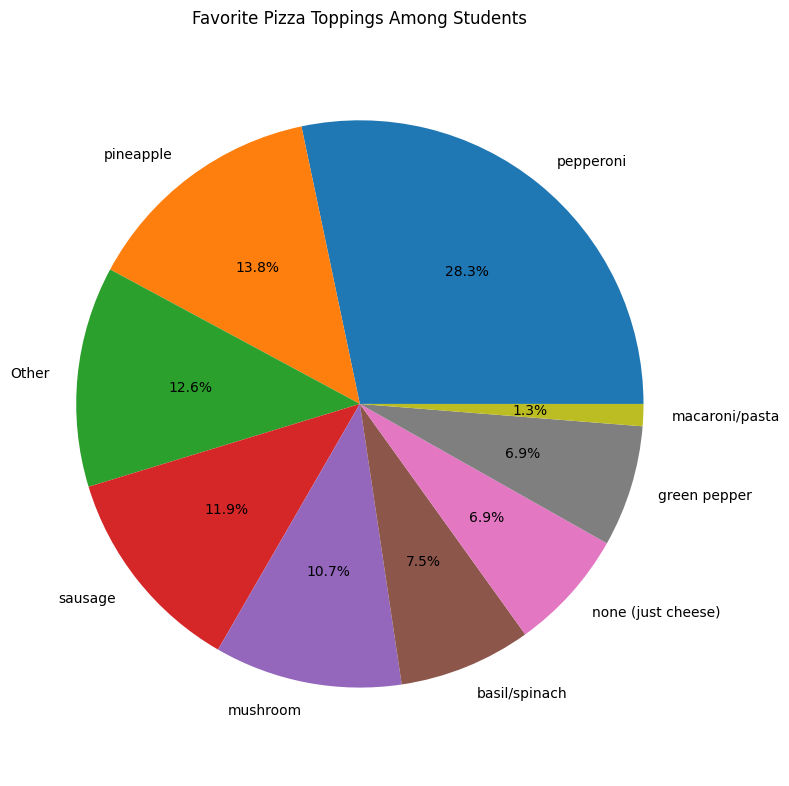

In [31]:
plt.figure(figsize=(8, 8))
plt.pie(q11['COUNT'], labels=q11['TOPPING'], autopct='%1.1f%%')
plt.title("Favorite Pizza Toppings Among Students")
plt.axis('equal') 
plt.tight_layout()
plt.show()

**Q12: How Many Juniors are in the Class?**

In [33]:
q12 = pd.read_sql("""
    SELECT COUNT(*) AS num_juniors
    FROM transform_survey
    WHERE standing = 'Junior'
""", conn)

q12

/tmp/ipykernel_2212783/1213941114.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  q12 = pd.read_sql("""


,NUM_JUNIORS
0,50


**Q13: What is the Most Common Reason for Students Taking the Course?**

In [34]:
q13 = pd.read_sql("""
    SELECT course_factor AS reason,
           COUNT(*) AS count
    FROM transform_survey
    WHERE course_factor IS NOT NULL
    GROUP BY course_factor
    ORDER BY count DESC
    LIMIT 1
""", conn)

q13

/tmp/ipykernel_2212783/4068866966.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  q13 = pd.read_sql("""


,REASON,COUNT
0,Interest in the subject,82


**Q14: How Many Students Have a Secondary Major?** 

In [36]:
q14 = pd.read_sql("""
    SELECT COUNT(*) AS num_with_secondary_major
    FROM transform_survey
    WHERE secondary_major IS NOT NULL
      AND TRIM(secondary_major) != ''
      AND LOWER(TRIM(secondary_major)) != 'none'
""", conn)

q14

/tmp/ipykernel_2212783/2642376567.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  q14 = pd.read_sql("""


,NUM_WITH_SECONDARY_MAJOR
0,66


**Q15: How Many Procrastinators are also Night Owls?**

In [42]:
q15 = pd.read_sql("""
    SELECT COUNT(*) AS num_procrastinating_night_owls
    FROM transform_survey
    WHERE is_procrastinator = 'Yes'
      AND early_or_night = 'night owl'
""", conn)

q15

/tmp/ipykernel_2212783/3325914994.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  q15 = pd.read_sql("""


,NUM_PROCRASTINATING_NIGHT_OWLS
0,68


**Q16: What is the Average Age of Students in the Course?**

In [47]:
q16 = pd.read_sql("""
    SELECT AVG(age) AS average_age
    FROM transform_survey
""", conn)

q16

/tmp/ipykernel_2212783/942217583.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  q16 = pd.read_sql("""


,AVERAGE_AGE
0,21.352201


**Q18**

In [1]:
!cat ~/.dbt/profiles.yml | grep -v password

p4_data_pipeline:
  target: dev # default target; can be switched using --target option of dbt run
  outputs:
    dev:
      type: snowflake
      account: JF80909.us-central1.gcp  # Example: <account_name>.<region>.<cloud_provider>
      user: SAMUELNEGUS
      role: p4_role
      database: survey_database 
      warehouse: p4_warehouse
      schema: survey_schema
      threads: 10
      
    stock_db:
      type: snowflake
      account: JF80909.us-central1.gcp
      user: SAMUELNEGUS
      role: p4_role
      database: stock_db
      warehouse: p4_warehouse
      schema: stock_schema
      threads: 10  


**Q19**

In [3]:
!cat ~/p4_data_pipeline/models/schema.yml

version: 2

sources:
  - name: survey
    database: survey_database
    schema: survey_schema
    tables:
      - name: survey

  - name: airbyte_csv_data
    database: survey_database
    schema: survey_schema
    tables:
      - name: trading_books
      - name: weights_table

  - name: stock_by_day
    database: STOCK_TRACKING_US_STOCK_PRICES_BY_DAY
    schema: STOCK
    tables:
      - name: us_stock_metrics

  - name: fx_by_day
    database: FOREX_TRACKING_CURRENCY_EXCHANGE
    schema: STOCK
    tables:
      - name: forex_metrics



**Q20**

In [6]:
!cat ~/p4_data_pipeline/dbt_project.yml


name: 'p4_data_pipeline'
version: '1.0.0'

profile: 'p4_data_pipeline'

model-paths: ["models"]
analysis-paths: ["analyses"]
test-paths: ["tests"]
seed-paths: ["seeds"]
macro-paths: ["macros"]
snapshot-paths: ["snapshots"]

clean-targets:         
  - "target"
  - "dbt_packages"


models:
  p4_data_pipeline:
    staging:
      +materialized: view
      +warehouse: p4_warehouse
    marts:
      +materialized: table
      +warehouse: p4_warehouse


**Q21**

In [2]:
!cat ~/p4_data_pipeline/models/staging/staging_valid_fx_tickers.sql

with base as (
  select distinct
    ticker,
    trade_date
  from {{ source('airbyte_csv_data', 'trading_books') }}
  where desk = 'FX Desk'
)

select * from base


In [3]:
!cat ~/p4_data_pipeline/models/staging/staging_valid_stock_tickers.sql

with base as (
  select distinct
    ticker,
    trade_date
  from {{ source('airbyte_csv_data', 'trading_books') }}
  where desk = 'Equity Desk'
)

select * from base


In [4]:
!cat ~/p4_data_pipeline/models/staging/staging_valid_stock_info.sql

with valid_tickers as (
  select * from {{ ref('staging_valid_stock_tickers') }}
),

stock_prices as (
  select
    ticker,
    run_date,
    open,
    close,
    high,
    low
  from {{ source('stock_by_day', 'us_stock_metrics') }}
)

select
  sp.*
from stock_prices sp
join valid_tickers vt
  on sp.ticker = vt.ticker
 and sp.run_date = vt.trade_date


In [5]:
!cat ~/p4_data_pipeline/models/staging/staging_valid_fx_info.sql

with valid_tickers as (
  select * from {{ ref('staging_valid_fx_tickers') }}
),

fx_prices as (
  select
    currency_pair_name as ticker,
    run_date,
    open,
    close,
    high,
    low
  from {{ source('fx_by_day', 'forex_metrics') }}
)

select
  fx.*
from fx_prices fx
join valid_tickers vt
  on fx.ticker = vt.ticker
 and fx.run_date = vt.trade_date


In [12]:
fx_tickers = pd.read_sql("SELECT * FROM staging_valid_fx_tickers", conn)
fx_tickers.to_csv("files/staging_valid_fx_tickers.csv", index=False)
stock_tickers = pd.read_sql("SELECT * FROM staging_valid_stock_tickers", conn)
stock_tickers.to_csv("files/staging_valid_stock_tickers.csv", index=False)

stock_info = pd.read_sql("SELECT * FROM staging_valid_stock_info", conn)
stock_info.to_csv("files/staging_valid_stock_info.csv", index=False)
fx_info = pd.read_sql("SELECT * FROM staging_valid_fx_info", conn)
fx_info.to_csv("files/staging_valid_fx_info.csv", index=False)

/tmp/ipykernel_2219033/529702796.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  fx_tickers = pd.read_sql("SELECT * FROM staging_valid_fx_tickers", conn)
/tmp/ipykernel_2219033/529702796.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  stock_tickers = pd.read_sql("SELECT * FROM staging_valid_stock_tickers", conn)
/tmp/ipykernel_2219033/529702796.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  stock_info = pd.read_sql("SELECT * FROM staging_valid_stock_info", conn)
/tmp/ipykernel_2219033/529702796.py:8: UserWarnin

**Q22**

In [14]:
!cat ~/p4_data_pipeline/models/staging/staging_buy_sell_joint.sql

with buys as (
  select
    trade_id,
    trade_date,
    trader_name,
    desk,
    ticker,
    quantity as quantity_buy,
    price as price_buy
  from {{ source('airbyte_csv_data', 'trading_books') }}
  where trade_type  = 'BUY'
),

sells as (
  select
    trade_id,
    trade_date,
    trader_name,
    desk,
    ticker,
    quantity as quantity_sell,
    price as price_sell
  from {{ source('airbyte_csv_data', 'trading_books') }}
  where trade_type  = 'SELL'
)

select
  b.trade_id,
  b.trade_date,
  b.trader_name,
  b.desk,
  b.ticker,
  b.quantity_buy,
  b.price_buy,
  s.quantity_sell,
  s.price_sell
from buys b
join sells s
  on b.trader_name = s.trader_name
 and b.trade_date = s.trade_date
 and b.ticker = s.ticker
 and b.desk = s.desk


In [15]:
joint = pd.read_sql("SELECT * FROM staging_buy_sell_joint", conn)
joint.to_csv("files/staging_buy_sell_joint.csv", index=False)

/tmp/ipykernel_2219033/1453525962.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  joint = pd.read_sql("SELECT * FROM staging_buy_sell_joint", conn)


**Q23**

In [16]:
!cat  ~/p4_data_pipeline/models/marts/fact_tab_trading.sql

{{ config(materialized='table') }}

select
  trade_id,
  price_buy * quantity_buy as buy_money,
  price_sell * quantity_sell as sell_money,
  (price_sell * quantity_sell) - (price_buy * quantity_buy) as profit
from {{ ref('staging_buy_sell_joint') }}
order by trade_id


In [17]:
fact = pd.read_sql("SELECT * FROM fact_tab_trading", conn)
fact.to_csv("files/fact_tab_trading.csv", index=False)

/tmp/ipykernel_2219033/3860786450.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  fact = pd.read_sql("SELECT * FROM fact_tab_trading", conn)


**Q24**

In [18]:
q24 = pd.read_sql("""
    SELECT
      b.desk,
      SUM(f.profit) AS total_profit
    FROM fact_tab_trading f
    JOIN staging_buy_sell_joint b
      ON f.trade_id = b.trade_id
    GROUP BY b.desk
    ORDER BY total_profit DESC
""", conn)

q24

/tmp/ipykernel_2219033/3706934093.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  q24 = pd.read_sql("""


,DESK,TOTAL_PROFIT
0,FX Desk,5000.00
1,Equity Desk,2718.75


**Q25**

In [19]:
q25 = pd.read_sql("""
    SELECT
      b.desk,
      SUM(f.sell_money - f.buy_money) / NULLIF(SUM(f.buy_money), 0) AS profit_rate
    FROM fact_tab_trading f
    JOIN staging_buy_sell_joint b
      ON f.trade_id = b.trade_id
    GROUP BY b.desk
    ORDER BY profit_rate DESC
""", conn)

q25

/tmp/ipykernel_2219033/746416868.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  q25 = pd.read_sql("""


,DESK,PROFIT_RATE
0,Equity Desk,0.012701
1,FX Desk,0.006342
